# Credit Card Fraud Detection with Decision Tree

## Business Context
Financial institutions lose billions annually to credit card fraud. This project uses a Decision Tree classifier to identify fraudulent transactions from legitimate ones, simulating a real-world fraud detection pipeline.

**Key objectives:**
- Handle imbalanced classification (rare fraud events)
- Build interpretable decision rules with tree visualization
- Evaluate with precision/recall (fraud cases are costly to miss)


# 综合实践--1 信用卡欺诈预测（Decision Tree）

> 数据集：`creditcard.csv`。  
>
**目标**：使用决策树完成信用卡欺诈预测的全流程，包括：数据探索、数据预处理、模型训练、剪枝与优化、可视化、特征重要性。


## 1. 数据导入与基本探索

- 读取 `creditcard.csv`
- 查看行列数、缺失值
- 统计 `Class` 类别分布并可视化
- `Amount`、`Time` 的描述统计


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1000 non-null   int64  
 1   V1      1000 non-null   float64
 2   V2      1000 non-null   float64
 3   V3      1000 non-null   float64
 4   V4      1000 non-null   float64
 5   V5      1000 non-null   float64
 6   V6      1000 non-null   float64
 7   V7      1000 non-null   float64
 8   V8      1000 non-null   float64
 9   V9      1000 non-null   float64
 10  V10     1000 non-null   float64
 11  Amount  1000 non-null   float64
 12  Class   1000 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 101.7 KB
None

(1000, 13)
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
Amount    0
Class     0
dtype: int64
Class
0    980
1     20
Name: count, dtype: int64


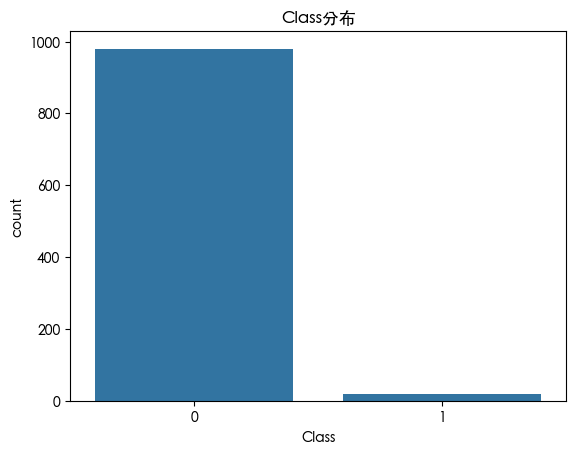

count    1000.000000
mean      114.063866
std        75.832771
min         0.019720
25%        55.903819
50%       104.989363
75%       161.074805
max       601.640667
Name: Amount, dtype: float64

count      1000.000000
mean      86194.539000
std       50008.474586
min         235.000000
25%       42052.250000
50%       89361.500000
75%      127614.750000
max      172627.000000
Name: Time, dtype: float64


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 设置中文字体，防止乱码
plt.rcParams['font.sans-serif'] = ['Heiti TC']      
plt.rcParams['axes.unicode_minus'] = False        # 解决负号显示问题     

data = pd.read_csv('../datasets/creditcard.csv')
print(data.info())
print()
print(data.shape)

missing_values = data.isnull().sum()
print(missing_values)

#class分布情况
class_distribution = data['Class'].value_counts()
print(class_distribution)
sns.countplot(x='Class', data=data)
plt.title('Class分布')
plt.show()

#amount\time描述性统计
amount_description = data['Amount'].describe()
time_description = data['Time'].describe()
print(amount_description)
print()
print(time_description)

## 2. 数据预处理

- 标准化 `Amount` 和 `Time`
- 分离特征 `X` 与标签 `y`
- 划分训练/测试集（80%/20%）


In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 标准化 Amount 和 Time
scaler = StandardScaler()
data[['Amount', 'Time']] = scaler.fit_transform(data[['Amount', 'Time']])
print(data.head())

#分离特征 和 标签
X = data.drop('Class', axis=1)
y = data['Class']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
# 输出划分后的数据集大小
print(f"训练集样本数: {X_train.shape[0]}, 测试集样本数: {X_test.shape[0]}")

       Time        V1        V2        V3        V4        V5        V6  \
0  0.715506 -1.313758 -1.095302 -0.168797  0.110956  0.786970 -0.891133   
1  1.213851  0.487360  0.555379 -0.104481  2.355580 -0.837748  0.610810   
2  0.915052  0.263894 -0.590478  0.374436  0.035148 -0.491973 -1.396629   
3  0.350105  0.551320 -0.435204 -1.095346 -0.217731 -1.124293  0.650190   
4  0.673912 -0.302467 -0.814964 -2.133133 -0.036533  0.128452  1.065861   

         V7        V8        V9       V10    Amount  Class  
0 -1.063109  0.138087 -0.258401  0.926721 -0.408194      0  
1 -1.269690 -1.073468 -0.607346  1.629323  1.326405      0  
2  1.438542  0.209818  2.173738  0.940322  1.096564      0  
3  1.632652 -0.260912  0.944491 -0.689229 -1.115286      0  
4  0.795438  0.808953 -0.974036  0.459497 -1.116358      0  
训练集样本数: 800, 测试集样本数: 200


## 3. 模型构建与训练（基线模型）

- 使用 `DecisionTreeClassifier(criterion='entropy', random_state=42)`
- 在测试集上评估：Accuracy/Precision/Recall/F1
- 输出分类报告与混淆矩阵


In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 创建，训练决策树分类器
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

# 在测试集上预测
y_pred = clf.predict(X_test)

# 计算评估指标
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(accuracy)
print(precision)
print(recall)
print(f1)
print("\n分类报告")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
print("\n混淆矩阵")
print(conf_matrix)


0.995
1.0
0.75
0.8571428571428571

分类报告
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       196
           1       1.00      0.75      0.86         4

    accuracy                           0.99       200
   macro avg       1.00      0.88      0.93       200
weighted avg       1.00      0.99      0.99       200


混淆矩阵
[[196   0]
 [  1   3]]


## 4. 模型剪枝与优化（深度搜索）

- 比较不同 `max_depth`（例如：3, 5, 10, 15, None）
- 绘制 **深度 vs Accuracy / Recall / F1** 折线图
- 根据结果选择合适的深度并分析过拟合/欠拟合


Max Depth: 1, Accuracy: 0.9900
Max Depth: 2, Accuracy: 0.9950
Max Depth: 3, Accuracy: 0.9950
Max Depth: 4, Accuracy: 0.9950
Max Depth: 5, Accuracy: 0.9950
Max Depth: 6, Accuracy: 0.9950
Max Depth: 7, Accuracy: 0.9950
Max Depth: 8, Accuracy: 0.9950
Max Depth: 9, Accuracy: 0.9950
Max Depth: 10, Accuracy: 0.9950
Max Depth: 15, Accuracy: 0.9950
Max Depth: None, Accuracy: 0.9950


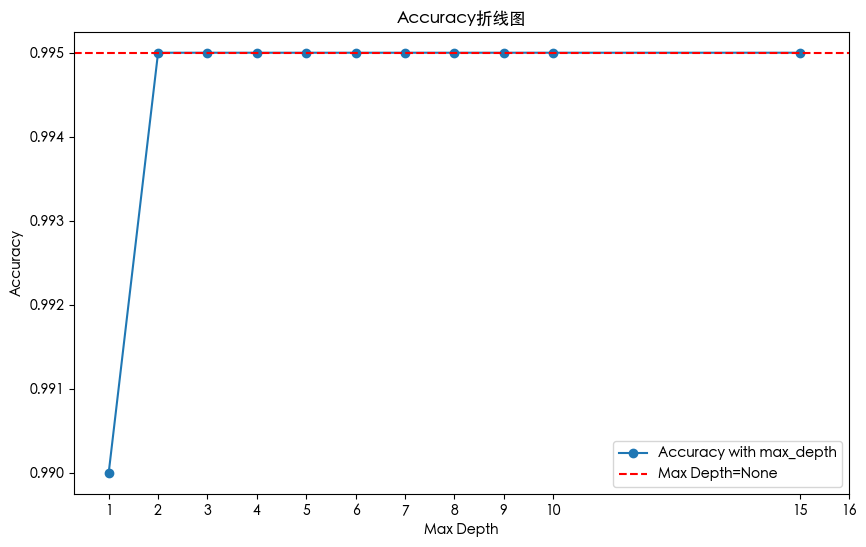

In [78]:
from sklearn.model_selection import train_test_split

max_depth_values = [1, 2, 3, 4, 5,6,7,8,9, 10, 15, None]
accuracy_scores = []

# 训练模型并计算准确率
for max_depth in max_depth_values:
    clf2 = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=max_depth)
    clf2.fit(X_train, y_train)
    y_pred2 = clf2.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred2)
    accuracy_scores.append(accuracy)
    print(f"Max Depth: {max_depth}, Accuracy: {accuracy:.4f}")

# 绘制 Accuracy 折线图
plt.figure(figsize=(10, 6))
plt.plot(max_depth_values[:-1], accuracy_scores[:-1], marker='o', label='Accuracy with max_depth')
plt.axhline(y=accuracy_scores[-1], color='r', linestyle='--', label='Max Depth=None')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy折线图')
plt.legend()
plt.xticks(max_depth_values[:-1] + [max_depth_values[-2] + 1])  
plt.show()



### 从画出的图上看出：max_depth为1时欠拟合

## 5. 模型可视化（决策树结构）

> 为避免图像过大，建议将 `max_depth` 设置为较小值（如 3–5）。


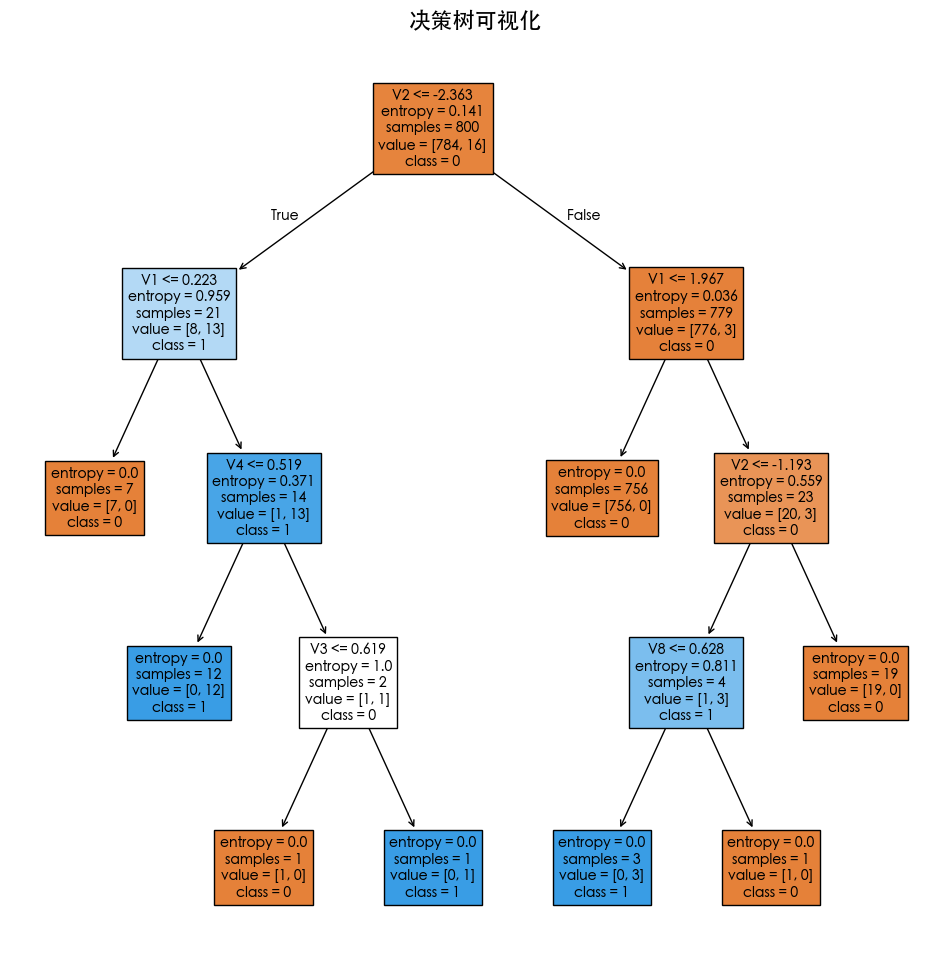

In [94]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

clf_plot = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)
clf_plot.fit(X_train, y_train)

plt.figure(figsize=(12, 12))
plot_tree(clf_plot, 
          filled=True,                                                                
          feature_names=X.columns,       # 显示特征名称
          class_names=['0', '1'],        # 显示类别名称
          fontsize=10)                               

# 4. 添加标题并显示图形
plt.title("决策树可视化", fontsize=16)
plt.show()


## 6. 决策树剪枝

- 使用 ccp_alpha 参数进行复杂度剪枝（Cost-Complexity Pruning）
    - 剪枝路径分析 ：计算不同 α 值下的剪枝路径
    - 不同剪枝强度下模型性能比较：遍历不同 ccp_alpha，记录训练与测试准确率

- 观察图中训练/测试准确率的变化趋势；

    - 找出“测试集准确率最高”的 α；

    - 分析模型过拟合/欠拟合变化。


8
ccp_alphas: 0.0000, Accuracy: 1.0000
ccp_alphas: 0.0025, Accuracy: 0.9988
ccp_alphas: 0.0040, Accuracy: 0.9988
ccp_alphas: 0.0041, Accuracy: 0.9975
ccp_alphas: 0.0120, Accuracy: 0.9950
ccp_alphas: 0.0187, Accuracy: 0.9862
ccp_alphas: 0.0194, Accuracy: 0.9862
ccp_alphas: 0.0808, Accuracy: 0.9800


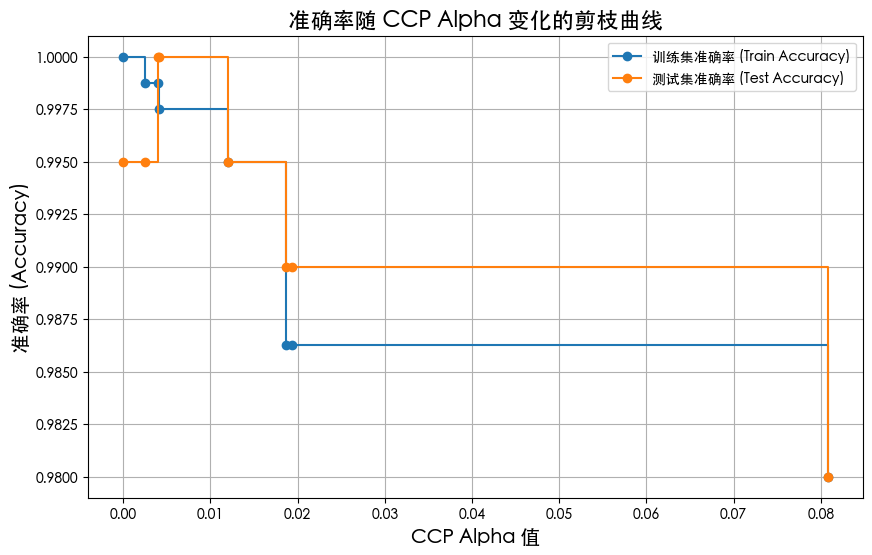

In [96]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas #找有效的ccp_alpha
print(len(ccp_alphas))

clfs = []
train_accuracy = []
test_accuracy = []
for alpha in ccp_alphas:
    #训练剪枝后的
    pruned_clf = DecisionTreeClassifier(criterion='entropy', random_state=42, ccp_alpha=alpha)
    pruned_clf.fit(X_train, y_train)
    
    # 计算在训练集和测试集上的准确率
    train_pred = pruned_clf.predict(X_train)
    test_pred = pruned_clf.predict(X_test)
     
    train_accuracy.append(accuracy_score(y_train, train_pred))
    test_accuracy.append(accuracy_score(y_test, test_pred))
    print(f"ccp_alphas: {alpha:.4f}, Accuracy: {accuracy_score(y_train, train_pred):.4f}")
    
# 画accuracy随ccp_alpha变化的折线图
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_accuracy, marker='o', label='训练集准确率 (Train Accuracy)', drawstyle="steps-post")
plt.plot(ccp_alphas, test_accuracy, marker='o', label='测试集准确率 (Test Accuracy)', drawstyle="steps-post")
plt.xlabel("CCP Alpha 值", fontsize=14)
plt.ylabel("准确率 (Accuracy)", fontsize=14)
plt.title("准确率随 CCP Alpha 变化的剪枝曲线", fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

## 分析图像
- alpha = 0.0040 时测试集准确率最高
- 当 alpha<0.0040 时模型是过拟合的，而alpha<0.0040 之后模型逐渐开始欠拟合

## 7. 特征重要性与解释

- 输出 `feature_importances_` 并按降序展示前 10 个
- 绘制前 10 个特征的重要性条形图


前 10 个最重要的特征及其重要性分数：
V2      0.687707
V1      0.282233
V8      0.030060
Time    0.000000
V3      0.000000
V4      0.000000
V5      0.000000
V6      0.000000
V7      0.000000
V9      0.000000
dtype: float64


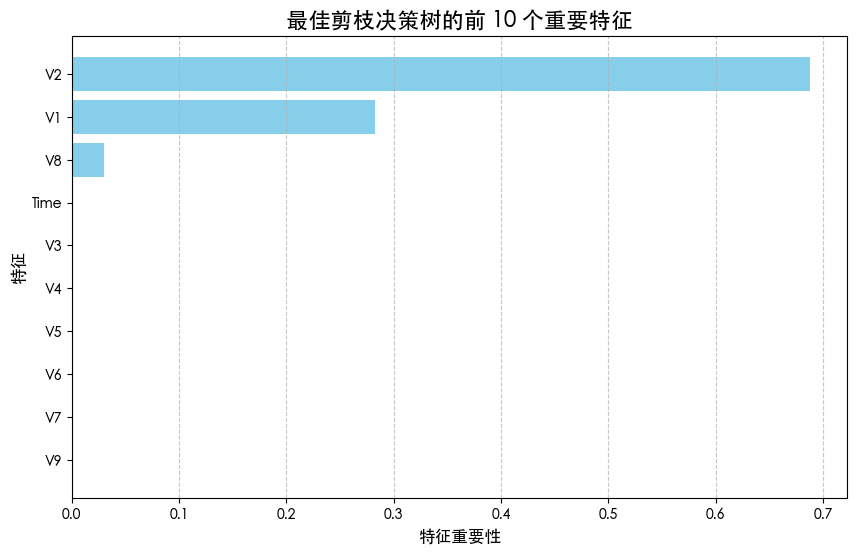

In [87]:
import numpy as np
import pandas as pd

best_alpha = 0.0040
# 使用最佳 alpha，重新训练最终模型
best_pruned_clf = DecisionTreeClassifier(criterion='entropy', random_state=42, ccp_alpha=best_alpha)
best_pruned_clf.fit(X_train, y_train)

# 获取特征重要性并按降序展示
feature_names = X_train.columns
importances = best_pruned_clf.feature_importances_
feature_importances = pd.Series(importances, index=feature_names)
sorted_importances = feature_importances.sort_values(ascending=False)

# 输出前 10 个最重要的特征
top_10_features = sorted_importances.head(10)
print("\n前 10 个最重要的特征及其重要性分数：")
print(top_10_features)

# 绘制前 10 个特征的重要性条形图
plt.figure(figsize=(10, 6))
# 使用水平条形图 (barh) 更适合展示特征名称
plt.barh(top_10_features.index[::-1], top_10_features.values[::-1], color='skyblue')
plt.xlabel("特征重要性", fontsize=12)
plt.ylabel("特征", fontsize=12)
plt.title("最佳剪枝决策树的前 10 个重要特征", fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## 8. 改进思路

请结合结果，简要回答：

1. 为什么信用卡欺诈数据普遍呈现**严重类别不平衡**？  
2. 决策树在不平衡数据上的常见问题有哪些？  
3. 你会采用哪些策略改进模型？（举例说明）
   - 调整 `class_weight`（如 `class_weight='balanced'`）
   - 调整 `min_samples_split`、`min_samples_leaf`
   - 采样策略：下采样 / 上采样（SMOTE 等）
   - 集成模型：随机森林、梯度提升树等


### 回答
- 1. 信用卡被欺诈就是小概率事件
- 2. (1)预测时会更多的识别为数量多的那一类
     (2)模型的泛化能力差
- 3. 以下我将尝试上采样的方法

SMOTE 处理后的训练集样本数: 1568
SMOTE 处理后的训练集标签分布:
 Class
0    784
1    784
Name: count, dtype: int64
Max Depth: 3 | Test Accuracy: 0.9950
Max Depth: 4 | Test Accuracy: 0.9950
Max Depth: 5 | Test Accuracy: 0.9900
Max Depth: 6 | Test Accuracy: 1.0000
Max Depth: 7 | Test Accuracy: 1.0000
Max Depth: 10 | Test Accuracy: 1.0000
Max Depth: 15 | Test Accuracy: 1.0000
Max Depth: 20 | Test Accuracy: 1.0000
Max Depth: None | Test Accuracy: 1.0000


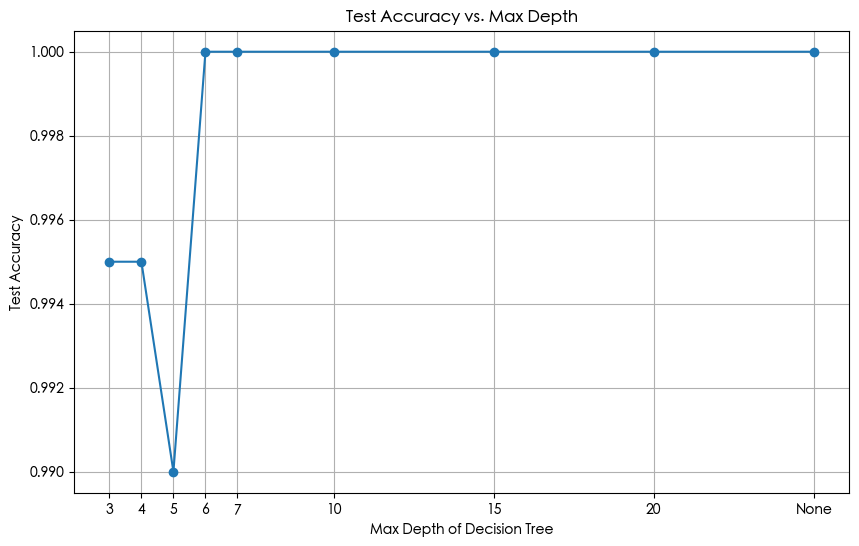

In [120]:
from imblearn.over_sampling import SMOTE
# 应用 SMOTE (仅对训练数据)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"SMOTE 处理后的训练集样本数: {X_train_smote.shape[0]}")
print("SMOTE 处理后的训练集标签分布:\n", y_train_smote.value_counts())

# 找最佳的 max_depth
max_depths = [3,4, 5,6,7, 10, 15, 20, None] 
test_accuracies = []
for depth in max_depths:
    model_depth = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    model_depth.fit(X_train_smote, y_train_smote)
    
    y_pred_depth = model_depth.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_depth)
    test_accuracies.append(accuracy)
    
    print(f"Max Depth: {depth:} | Test Accuracy: {accuracy:.4f}")
    
# 4. 绘制 Accuracy 折线图
plt.figure(figsize=(10, 6))
plt.plot(plot_depths, test_accuracies, marker='o', linestyle='-')
plt.xticks(plot_depths, labels=plot_labels) # 设置x轴刻度标签
plt.title('Test Accuracy vs. Max Depth')
plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()


[0.         0.0025     0.00399657 0.00405639 0.0120042  0.01866962
 0.01941602 0.08079774]


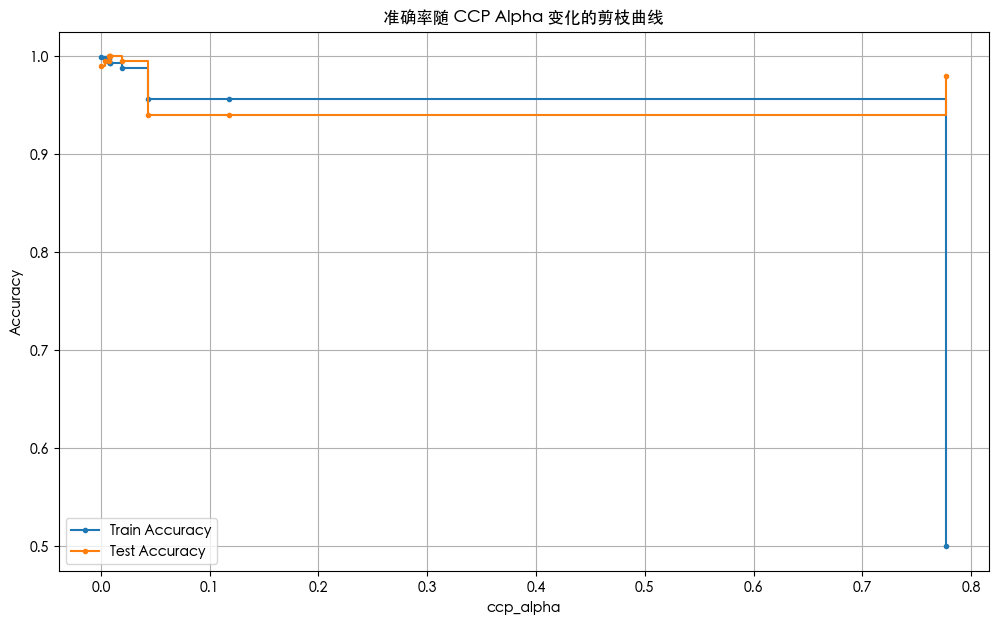

In [128]:
# 剪枝
# 获取不同 alpha 值对应的剪枝路径
path_model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)
path = path_model.cost_complexity_pruning_path(X_train_smote, y_train_smote)
ccp_alphas2 = path.ccp_alphas
print(ccp_alphas)

train_scores2 = []
test_scores2 = []

for alpha2 in ccp_alphas2:
    model_alpha = DecisionTreeClassifier(criterion='entropy',ccp_alpha=alpha2,random_state=42, max_depth=5)
    model_alpha.fit(X_train_smote, y_train_smote)
    
    # 记录训练集和测试集的准确率
    train_scores2.append(model_alpha.score(X_train_smote, y_train_smote))
    test_scores2.append(model_alpha.score(X_test, y_test))

# 3. 绘制准确率随 ccp_alpha 改变的图
plt.figure(figsize=(12, 7))
plt.plot(ccp_alphas2, train_scores2, marker='.', label='Train Accuracy', drawstyle="steps-post")
plt.plot(ccp_alphas2, test_scores2, marker='.', label='Test Accuracy', drawstyle="steps-post")
plt.title('准确率随 CCP Alpha 变化的剪枝曲线')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### 由以上的尝试发现最佳的最大树的深度为max_depth = 5,最佳ccp_alpha = 0.0040


### 但是我不知道在画“准确率随 CCP Alpha 变化的剪枝曲线”时，最后test accuracy为什么还要增加以下。而且我觉得这个准确率有点太高了。。。感觉模型的泛化能力依然不是很好。